# OntoNotes5 (tner/ontonotes5) Dataset Analysis

This notebook analyzes a 250-example subset of the OntoNotes5 NER dataset (via `tner/ontonotes5`) used in this project.

Target NER classes:
- Person
- Location
- Organization
- Time
- Currency


In [38]:
import json
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_PATH = "ontonotes5_raw_ner_250.json"

# Original OntoNotes label mapping (name -> id)
LABEL_NAME2ID = {
    "O": 0,
    "B-CARDINAL": 1,
    "B-DATE": 2,
    "I-DATE": 3,
    "B-PERSON": 4,
    "I-PERSON": 5,
    "B-NORP": 6,
    "B-GPE": 7,
    "I-GPE": 8,
    "B-LAW": 9,
    "I-LAW": 10,
    "B-ORG": 11,
    "I-ORG": 12,
    "B-PERCENT": 13,
    "I-PERCENT": 14,
    "B-ORDINAL": 15,
    "B-MONEY": 16,
    "I-MONEY": 17,
    "B-WORK_OF_ART": 18,
    "I-WORK_OF_ART": 19,
    "B-FAC": 20,
    "B-TIME": 21,
    "I-CARDINAL": 22,
    "B-LOC": 23,
    "B-QUANTITY": 24,
    "I-QUANTITY": 25,
    "I-NORP": 26,
    "I-LOC": 27,
    "B-PRODUCT": 28,
    "I-TIME": 29,
    "B-EVENT": 30,
    "I-EVENT": 31,
    "I-FAC": 32,
    "B-LANGUAGE": 33,
    "I-PRODUCT": 34,
    "I-ORDINAL": 35,
    "I-LANGUAGE": 36,
}

# Inverse mapping (id -> name) for convenience
LABEL_ID2NAME = {v: k for k, v in LABEL_NAME2ID.items()}


In [39]:
# Load dataset
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset file not found: {DATA_PATH}. Run the data loader first.")

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

# Map numeric label IDs to OntoNotes string labels using LABEL_ID2NAME
for item in data:
    mapped = []
    for lab in item["labels"]:
        # lab is an int (or stringified int in some edge cases)
        try:
            lab_id = int(lab)
        except ValueError:
            # Already a string label (e.g., "B-PERSON")
            mapped.append(str(lab))
            continue
        mapped.append(LABEL_ID2NAME.get(lab_id, "O"))
    item["labels"] = mapped

print(f"Dataset loaded: {len(data)} sentences")
print("Labels converted from IDs to OntoNotes tag strings.")


Dataset loaded: 250 sentences
Labels converted from IDs to OntoNotes tag strings.


Label distribution (original OntoNotes tags):
O              :  5104
I-DATE         :   145
I-ORG          :   114
B-DATE         :   111
B-PERSON       :   111
I-MONEY        :    99
B-ORG          :    98
B-GPE          :    91
I-PERSON       :    60
I-PERCENT      :    51
B-MONEY        :    47
B-PERCENT      :    38
B-CARDINAL     :    28
B-NORP         :    25
I-WORK_OF_ART  :    12
I-CARDINAL     :    10
B-WORK_OF_ART  :     9
I-GPE          :     8
B-ORDINAL      :     4
B-LOC          :     3
I-LAW          :     2
I-QUANTITY     :     2
B-LAW          :     1
B-FAC          :     1
B-TIME         :     1
B-QUANTITY     :     1


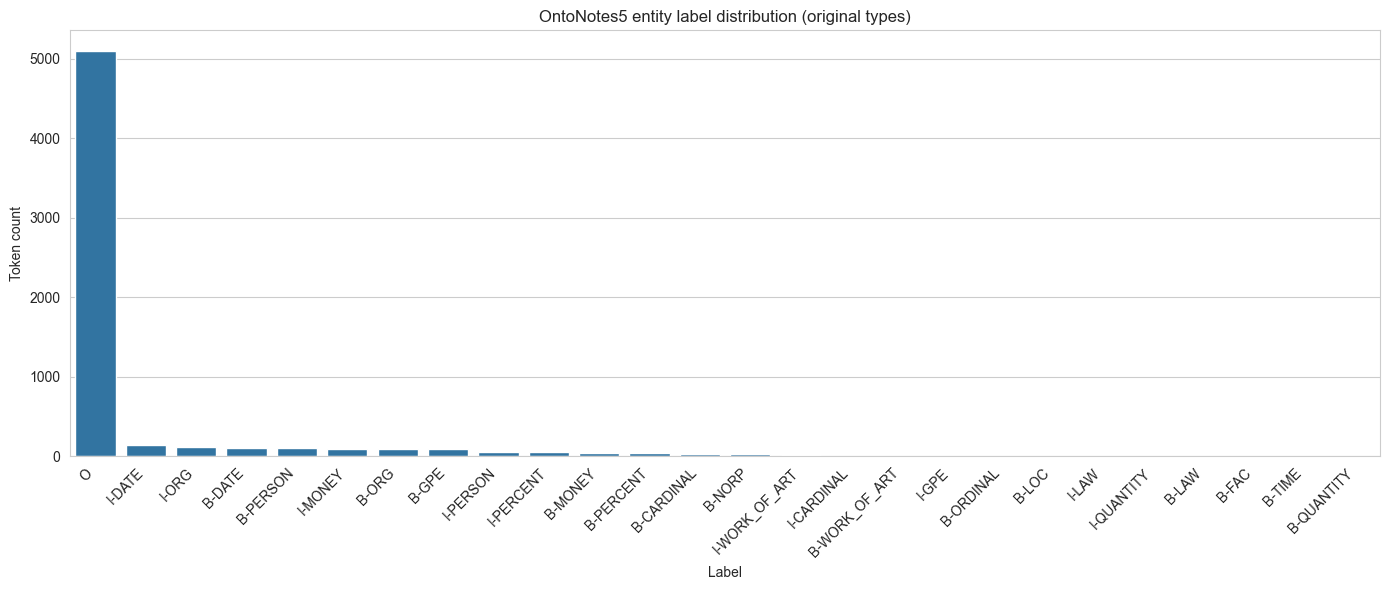

In [40]:
# Simple visualization of OntoNotes5 original entity types
from collections import Counter

# Flatten all labels
all_labels = [lab for item in data for lab in item["labels"]]
label_counts = Counter(all_labels)

print("Label distribution (original OntoNotes tags):")
for lab, cnt in sorted(label_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{lab:15s}: {cnt:5d}")

# Bar plot of label frequencies
labels, counts = zip(*sorted(label_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(14, 6))
sns.barplot(x=list(labels), y=list(counts))
plt.xticks(rotation=45, ha="right")
plt.title("OntoNotes5 entity label distribution (original types)")
plt.ylabel("Token count")
plt.xlabel("Label")
plt.tight_layout()
plt.show()


## 1. Basic Statistics


In [41]:
# Basic statistics
sentence_lengths = [len(item["tokens"]) for item in data]
text_lengths = [len(item["text"]) for item in data]

stats = {
    "Total Sentences": len(data),
    "Total Tokens": sum(sentence_lengths),
    "Avg Tokens per Sentence": np.mean(sentence_lengths),
    "Median Tokens per Sentence": np.median(sentence_lengths),
    "Min Tokens": np.min(sentence_lengths),
    "Max Tokens": np.max(sentence_lengths),
    "Avg Text Length": np.mean(text_lengths),
    "Median Text Length": np.median(text_lengths),
}

for key, value in stats.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")


Total Sentences: 250
Total Tokens: 6176
Avg Tokens per Sentence: 24.70
Median Tokens per Sentence: 24.00
Min Tokens: 3
Max Tokens: 57
Avg Text Length: 132.47
Median Text Length: 132.50


## 2. Entity Type Distribution (5 Classes)


In [42]:
PROJECT_ENTITY_TYPES = ["PERSON", "LOCATION", "ORGANIZATION", "TIME", "CURRENCY"]

entity_counts = {t: 0 for t in PROJECT_ENTITY_TYPES}
entity_mentions = {t: 0 for t in PROJECT_ENTITY_TYPES}

for item in data:
    labels = item["labels"]
    current_entity = None

    for label in labels:
        if label.startswith("B-"):
            # end previous
            if current_entity is not None:
                entity_counts[current_entity] += 1
            ent = label[2:]
            if ent in entity_mentions:
                entity_mentions[ent] += 1
                current_entity = ent
        elif label.startswith("I-"):
            ent = label[2:]
            if ent == current_entity:
                entity_mentions[ent] += 1
            else:
                # new entity starting with I-
                if current_entity is not None:
                    entity_counts[current_entity] += 1
                if ent in entity_mentions:
                    entity_mentions[ent] += 1
                    current_entity = ent
        else:
            if current_entity is not None:
                entity_counts[current_entity] += 1
                current_entity = None

    if current_entity is not None:
        entity_counts[current_entity] += 1

print("Entity Distribution (5 classes):")
print("=" * 60)
for ent in PROJECT_ENTITY_TYPES:
    print(f"{ent}:")
    print(f"  Entities: {entity_counts[ent]}")
    print(f"  Token Mentions: {entity_mentions[ent]}")
    print()


Entity Distribution (5 classes):
PERSON:
  Entities: 111
  Token Mentions: 171

LOCATION:
  Entities: 0
  Token Mentions: 0

ORGANIZATION:
  Entities: 0
  Token Mentions: 0

TIME:
  Entities: 1
  Token Mentions: 1

CURRENCY:
  Entities: 0
  Token Mentions: 0



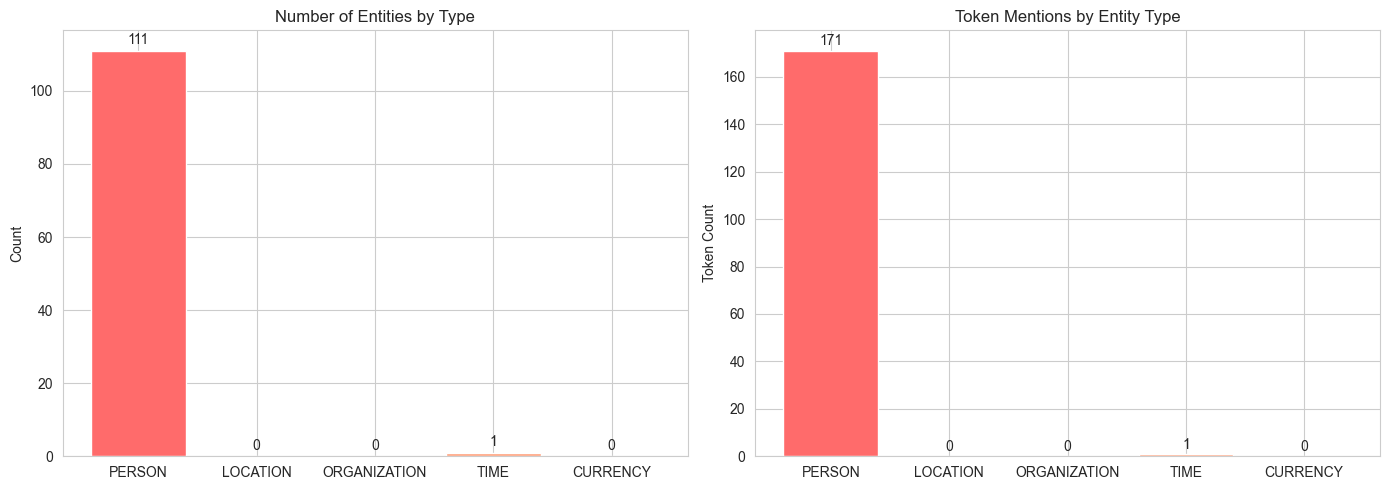

In [43]:
# Visualize entity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

etypes = PROJECT_ENTITY_TYPES
counts = [entity_counts[e] for e in etypes]
mentions = [entity_mentions[e] for e in etypes]

axes[0].bar(etypes, counts, color=["#FF6B6B", "#4ECDC4", "#45B7D1", "#FFA07A", "#95A5A6"])
axes[0].set_title("Number of Entities by Type")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts):
    axes[0].text(i, v + 1, str(v), ha="center", va="bottom")

axes[1].bar(etypes, mentions, color=["#FF6B6B", "#4ECDC4", "#45B7D1", "#FFA07A", "#95A5A6"])
axes[1].set_title("Token Mentions by Entity Type")
axes[1].set_ylabel("Token Count")
for i, v in enumerate(mentions):
    axes[1].text(i, v + 1, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()


## 3. Sentence Length Distribution


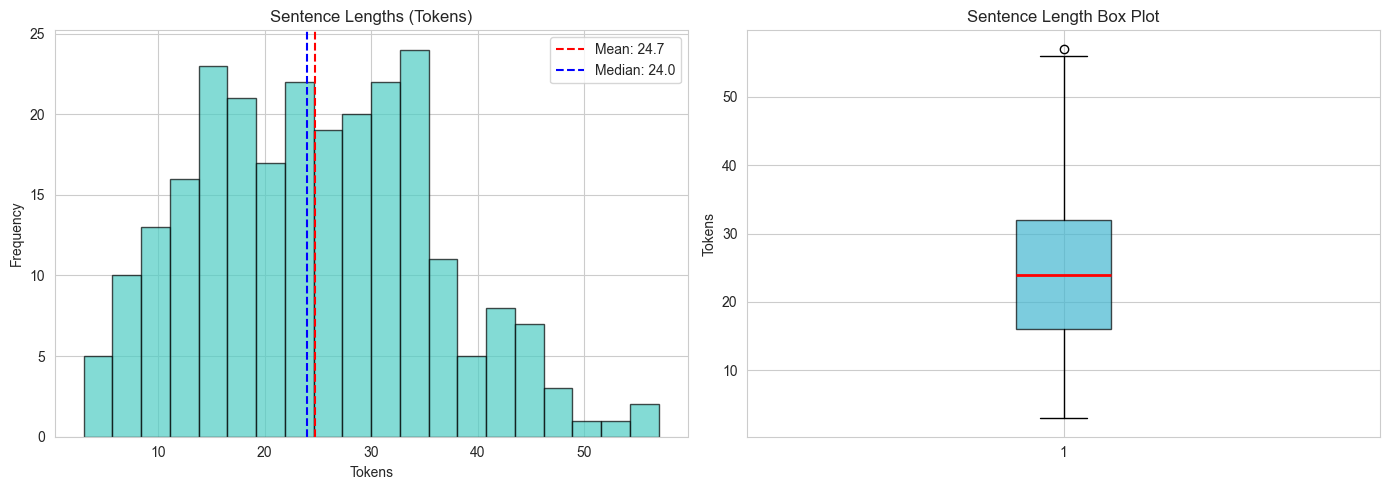

In [44]:
# Visualize sentence length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sentence_lengths, bins=20, color="#4ECDC4", edgecolor="black", alpha=0.7)
axes[0].set_title("Sentence Lengths (Tokens)")
axes[0].set_xlabel("Tokens")
axes[0].set_ylabel("Frequency")
axes[0].axvline(np.mean(sentence_lengths), color="red", linestyle="--", label=f"Mean: {np.mean(sentence_lengths):.1f}")
axes[0].axvline(np.median(sentence_lengths), color="blue", linestyle="--", label=f"Median: {np.median(sentence_lengths):.1f}")
axes[0].legend()

axes[1].boxplot(sentence_lengths, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#45B7D1", alpha=0.7),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Sentence Length Box Plot")
axes[1].set_ylabel("Tokens")

plt.tight_layout()
plt.show()


## 4. Label Distribution


In [45]:
all_labels = []
for item in data:
    all_labels.extend(item["labels"])

label_counts = Counter(all_labels)

print("Label Distribution (BIO):")
print("=" * 60)
for lab, cnt in label_counts.most_common():
    pct = cnt / len(all_labels) * 100
    print(f"{lab:15s}: {cnt:5d} ({pct:5.2f}%)")


Label Distribution (BIO):
O              :  5104 (82.64%)
I-DATE         :   145 ( 2.35%)
I-ORG          :   114 ( 1.85%)
B-DATE         :   111 ( 1.80%)
B-PERSON       :   111 ( 1.80%)
I-MONEY        :    99 ( 1.60%)
B-ORG          :    98 ( 1.59%)
B-GPE          :    91 ( 1.47%)
I-PERSON       :    60 ( 0.97%)
I-PERCENT      :    51 ( 0.83%)
B-MONEY        :    47 ( 0.76%)
B-PERCENT      :    38 ( 0.62%)
B-CARDINAL     :    28 ( 0.45%)
B-NORP         :    25 ( 0.40%)
I-WORK_OF_ART  :    12 ( 0.19%)
I-CARDINAL     :    10 ( 0.16%)
B-WORK_OF_ART  :     9 ( 0.15%)
I-GPE          :     8 ( 0.13%)
B-ORDINAL      :     4 ( 0.06%)
B-LOC          :     3 ( 0.05%)
I-LAW          :     2 ( 0.03%)
I-QUANTITY     :     2 ( 0.03%)
B-LAW          :     1 ( 0.02%)
B-FAC          :     1 ( 0.02%)
B-TIME         :     1 ( 0.02%)
B-QUANTITY     :     1 ( 0.02%)
